In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.modeling import models
import astropy.units as u

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [4]:
image_cut = image[52:172, 0:1890]
image_error_cut = image_error[52:172, 0:1890]

Text(0.5, 0, 'wavelenght')

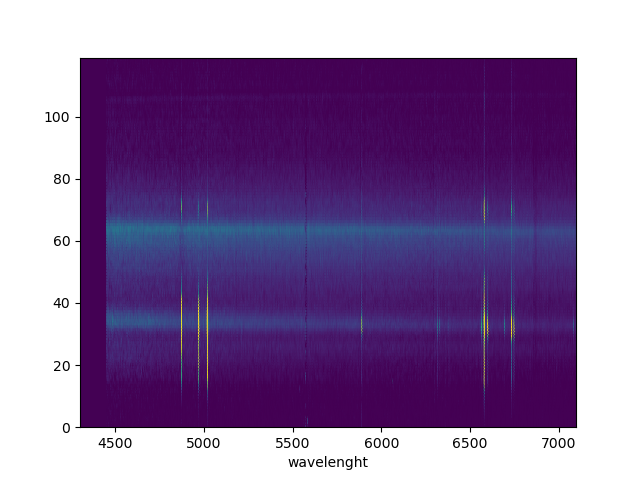

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.00309
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

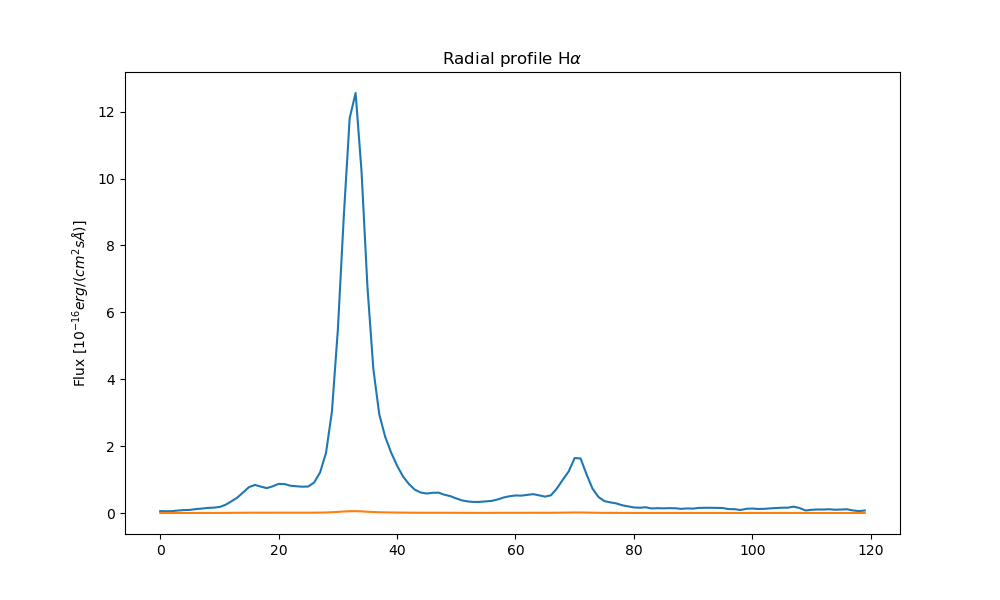

In [7]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

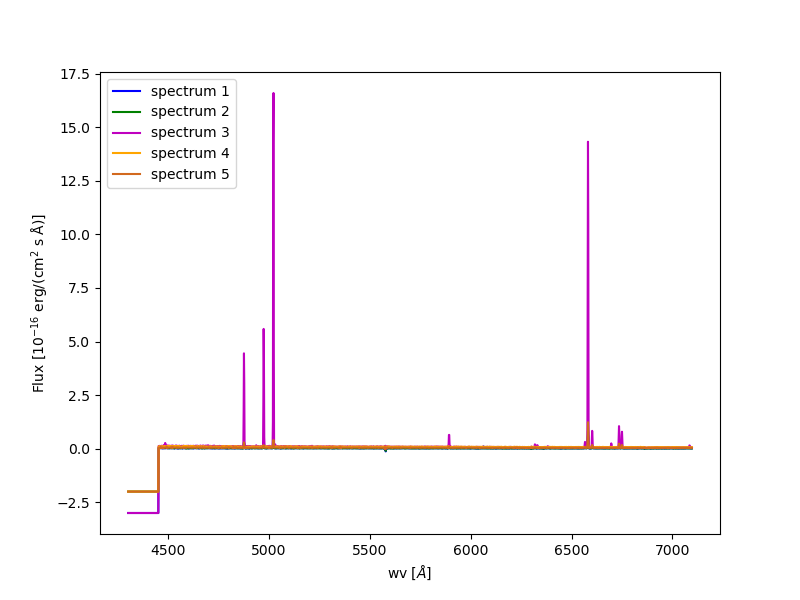

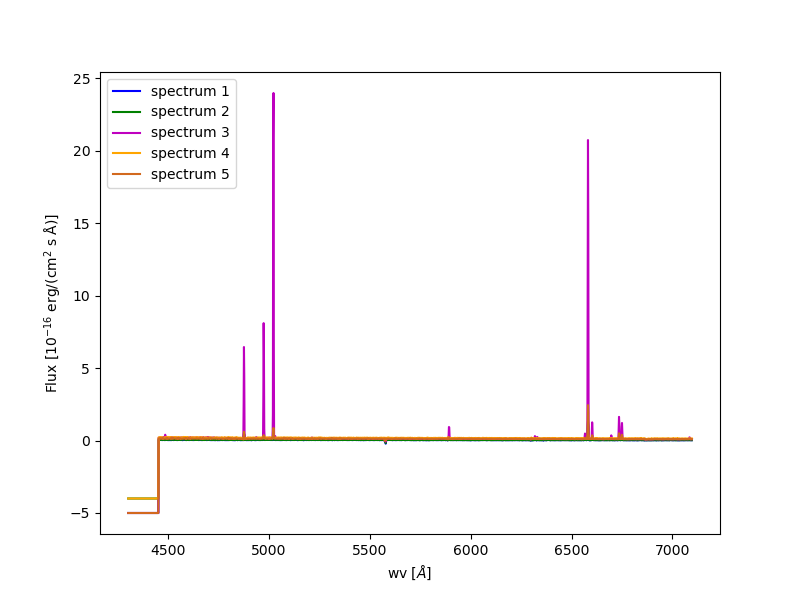

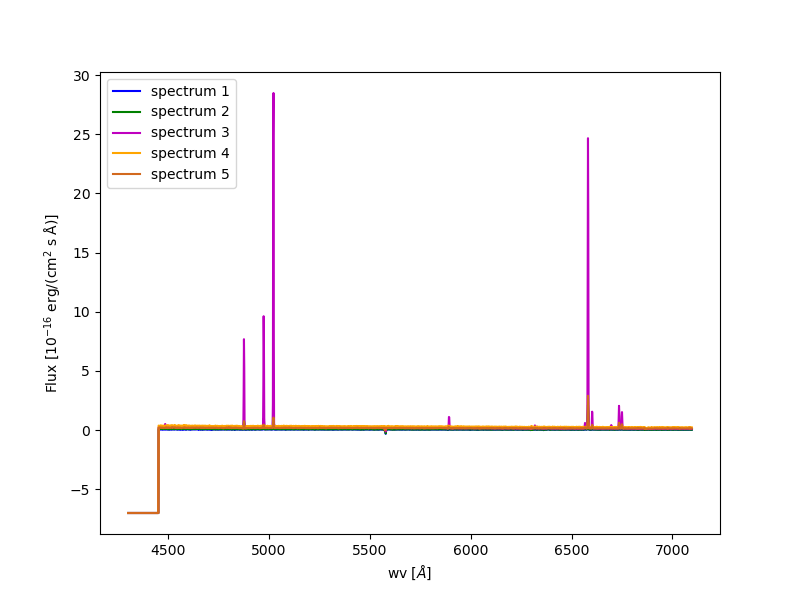

In [8]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/Fit/5_peaks/Halpha_fit.csv", index_col=0)
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049\MCG+01-32-049_1/FORS2.2022-01-29T07_05_26.457/PSF/Real_seeing_MGC+01-32-049.txt")
sigma = seeing[-1]/2.35
peaks = fit_HA.iloc[3].values

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green','m', 'orange', 'chocolate']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_1[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('1Sigma', f'Spectrum_1s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*sigma)*(x_axes < peaks[i]+2*sigma)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_2[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('2Sigma', f'Spectrum_2s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)
    
plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*sigma)*(x_axes < peaks[i]+3*sigma)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_3[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('3Sigma', f'Spectrum_3s_{i+1}.txt') 
    np.savetxt(filename, spectrum_table)

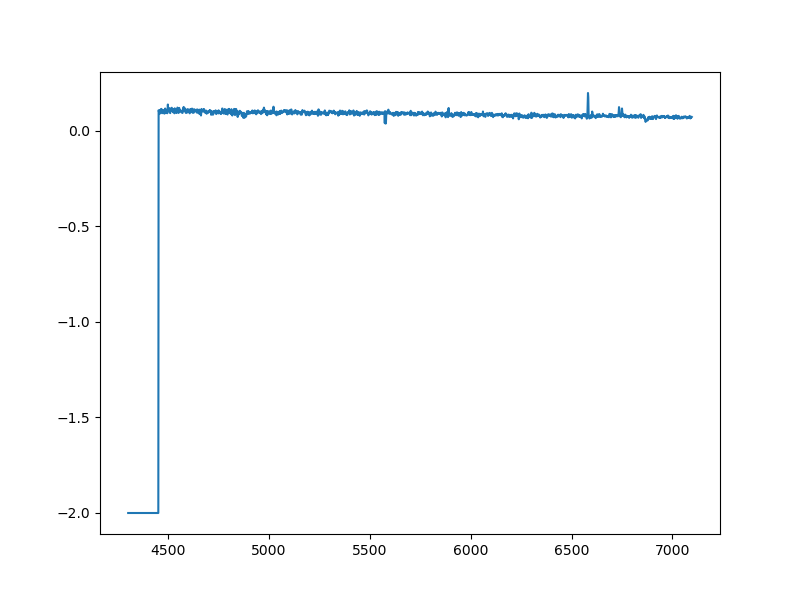

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(wv, spectra_1[3])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [62]:
import pandas as pd

mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5100)*(wv < 5400)
mask_continuum_3 = (wv > 5910)*(wv < 6210)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_1[i, mask_continuum_1])
    noise_1 = np.std(spectra_1[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_1[i, mask_continuum_2])
    noise_2 = np.std(spectra_1[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_1[i, mask_continuum_3])
    noise_3 = np.std(spectra_1[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df_path_signal = os.path.join('1Sigma', 'Signal_1s_continuum.csv')
df_path_noise = os.path.join('1Sigma', 'Noise_1s_continuum.csv')
df_path_combined = os.path.join('1Sigma', 'Combined_1s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('1Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    3.376840    4.482327   11.765834   11.776992    8.478284
Continuum_2    5.234664    5.700934   13.047429   13.755119   10.333233
Continuum_3    2.251912    4.800446   12.209543   13.820435   11.240374

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.024286    0.027696    0.124419    0.101085    0.051517
Continuum_2    0.023064    0.022067    0.100626    0.092770    0.050522
Continuum_3    0.019443    0.016889    0.078636    0.082558    0.046648

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.007192    0.006179    0.010575    0.008583    0.006076
Continuum_2    0.004406    0.003871    0.007712    0.006744    0.004889
Continuum_3    0.008634    0.003518    0.006441    0.005974    0.004150

DataFrame Combinato:
                   SNR                                        

In [63]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_2[i, mask_continuum_1])
    noise_1 = np.std(spectra_2[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_2[i, mask_continuum_2])
    noise_2 = np.std(spectra_2[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_2[i, mask_continuum_3])
    noise_3 = np.std(spectra_2[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df_path_signal = os.path.join('2Sigma', 'Signal_2s_continuum.csv')
df_path_noise = os.path.join('2Sigma', 'Noise_2s_continuum.csv')
df_path_combined = os.path.join('2Sigma', 'Combined_2s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('2Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    4.426325    5.767954   13.039444   14.943855   12.289961
Continuum_2    6.479911    7.797022   14.252326   17.169688   13.863945
Continuum_3    3.203126    6.323662   13.626367   18.611543   15.685444

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.041123    0.056202    0.192968    0.206247    0.139164
Continuum_2    0.038128    0.044762    0.156332    0.189156    0.132354
Continuum_3    0.031368    0.034426    0.120426    0.168608    0.120652

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.009290    0.009744    0.014799    0.013801    0.011323
Continuum_2    0.005884    0.005741    0.010969    0.011017    0.009547
Continuum_3    0.009793    0.005444    0.008838    0.009059    0.007692

DataFrame Combinato:
                   SNR                                        

In [64]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_3[i, mask_continuum_1])
    noise_1 = np.std(spectra_3[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_3[i, mask_continuum_2])
    noise_2 = np.std(spectra_3[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_3[i, mask_continuum_3])
    noise_3 = np.std(spectra_3[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df_path_signal = os.path.join('3Sigma', 'Signal_3s_continuum.csv')
df_path_noise = os.path.join('3Sigma', 'Noise_3s_continuum.csv')
df_path_combined = os.path.join('3Sigma', 'Combined_3s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('3Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    5.216148    7.040851   13.565687   19.042344   13.869600
Continuum_2    7.508155    9.507086   14.607446   19.239358   15.151045
Continuum_3    4.139550    7.738758   14.487682   21.889463   18.107149

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.058893    0.095905    0.252851    0.366151    0.202119
Continuum_2    0.053009    0.077179    0.203416    0.333227    0.189915
Continuum_3    0.043555    0.059357    0.155908    0.292572    0.171544

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5
Continuum_1    0.011291    0.013621    0.018639    0.019228    0.014573
Continuum_2    0.007060    0.008118    0.013926    0.017320    0.012535
Continuum_3    0.010522    0.007670    0.010761    0.013366    0.009474

DataFrame Combinato:
                   SNR                                        

## Redshift

In [65]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Spettro 1
Numero di righe trovate (regione centrale, wv > 4451 Å): 9
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
 4874.97999999983   emission               268
4972.659999999802   emission               334
5021.499999999787   emission               367
6581.419999999327   emission              1421
6602.139999999321   emission              1435
6735.339999999282   emission              1525
6750.139999999277   emission              1535
5573.539999999624 absorption               740
5577.979999999623 absorption               743
Spettro 2
Numero di righe trovate (regione centrale, wv > 4451 Å): 9
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
 4874.97999999983   emission               268
4972.659999999802   emission               334
5021.499999999787   emission               367
6581.41999999932

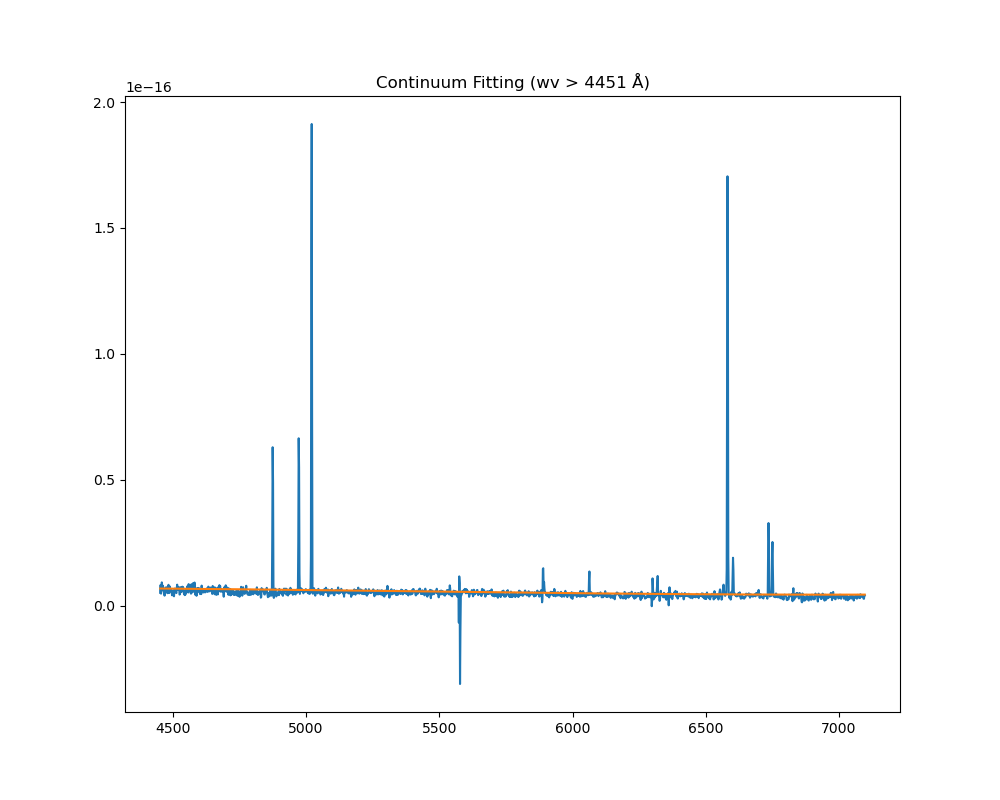

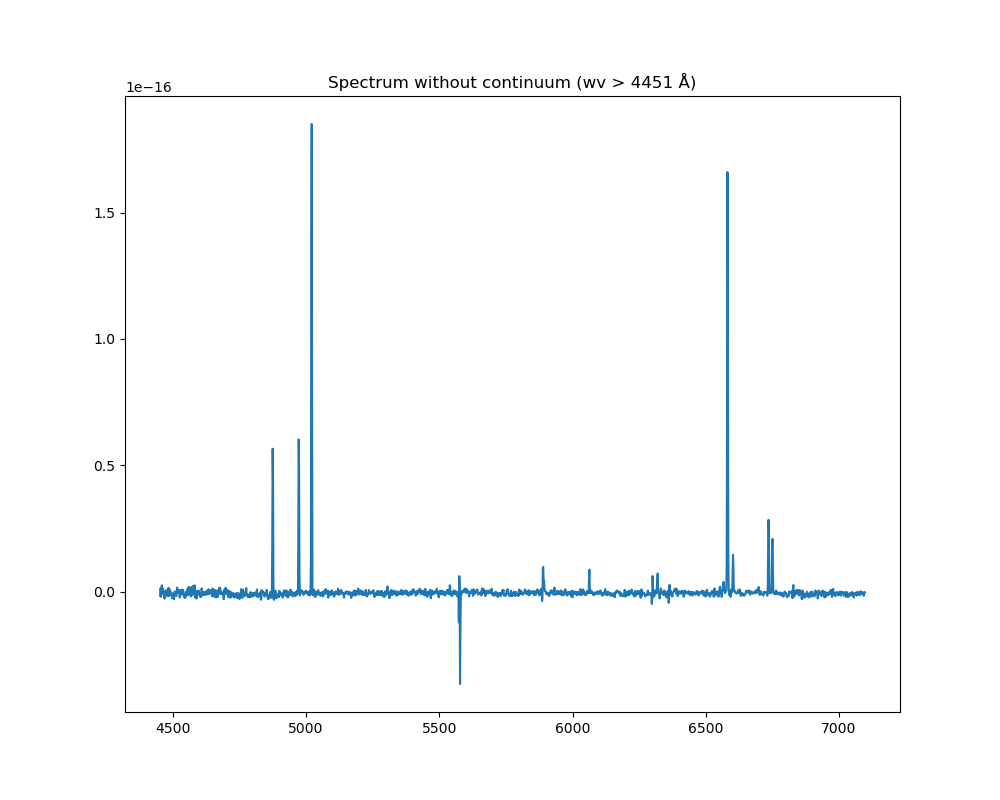

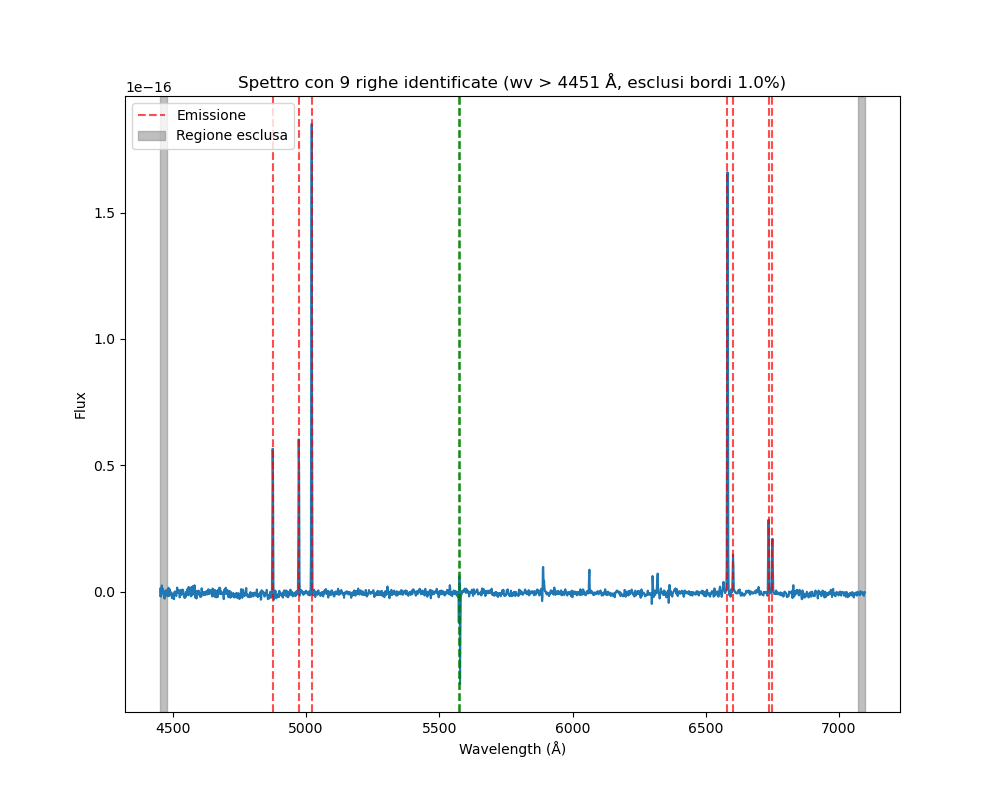

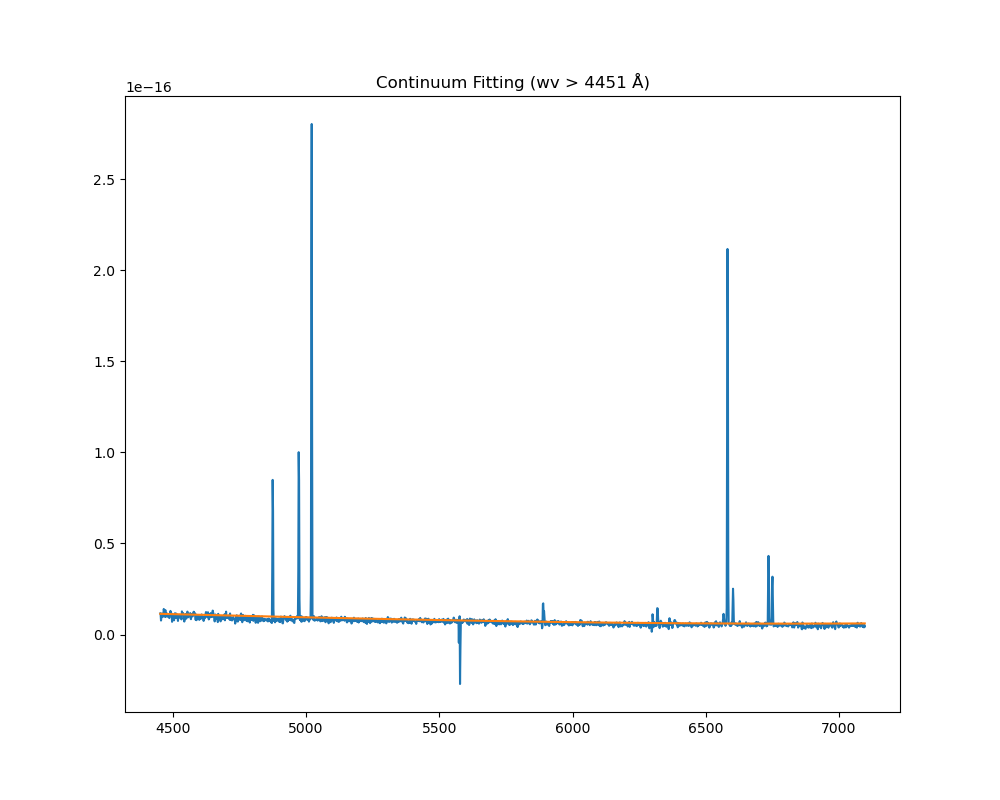

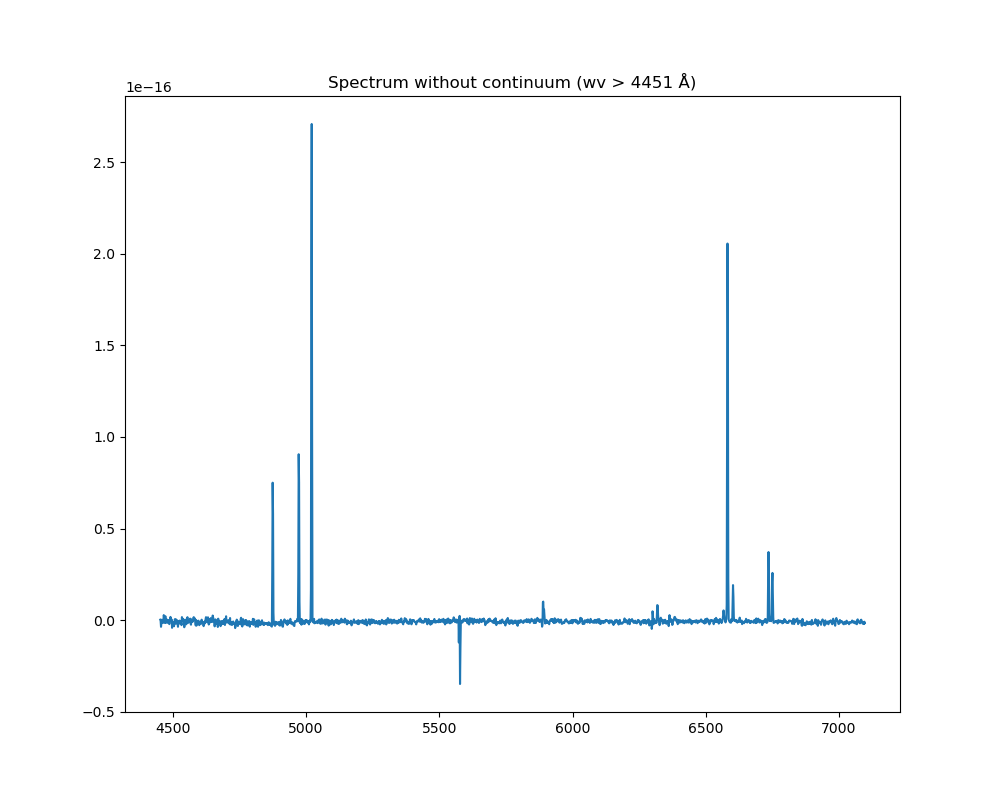

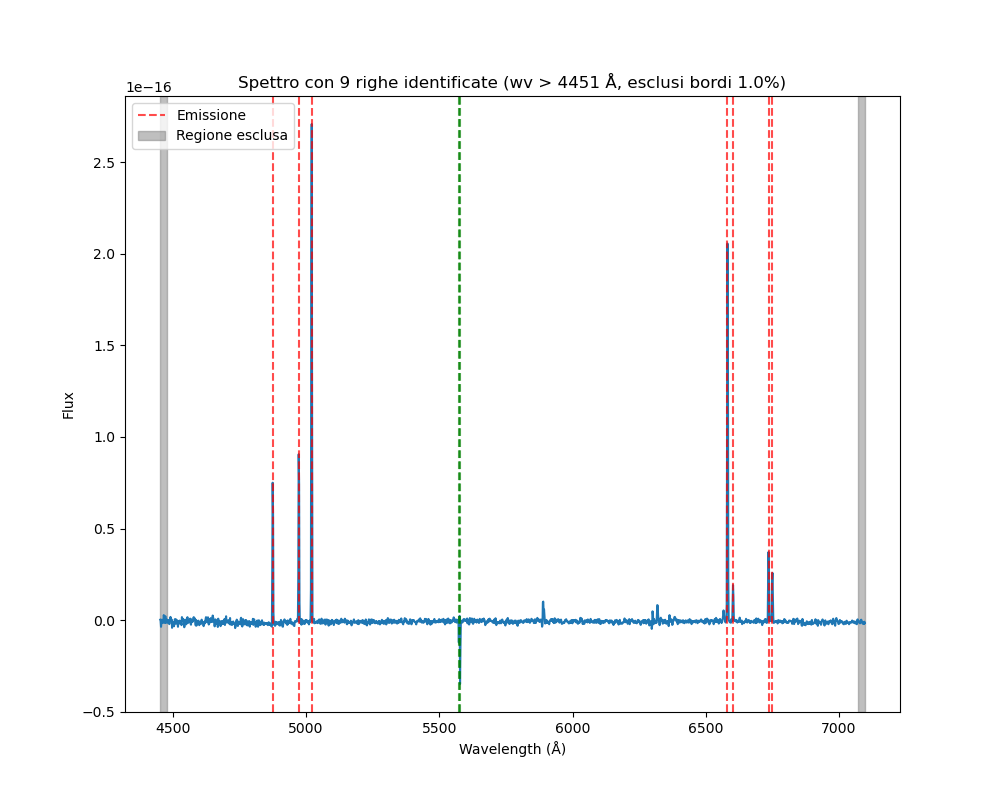

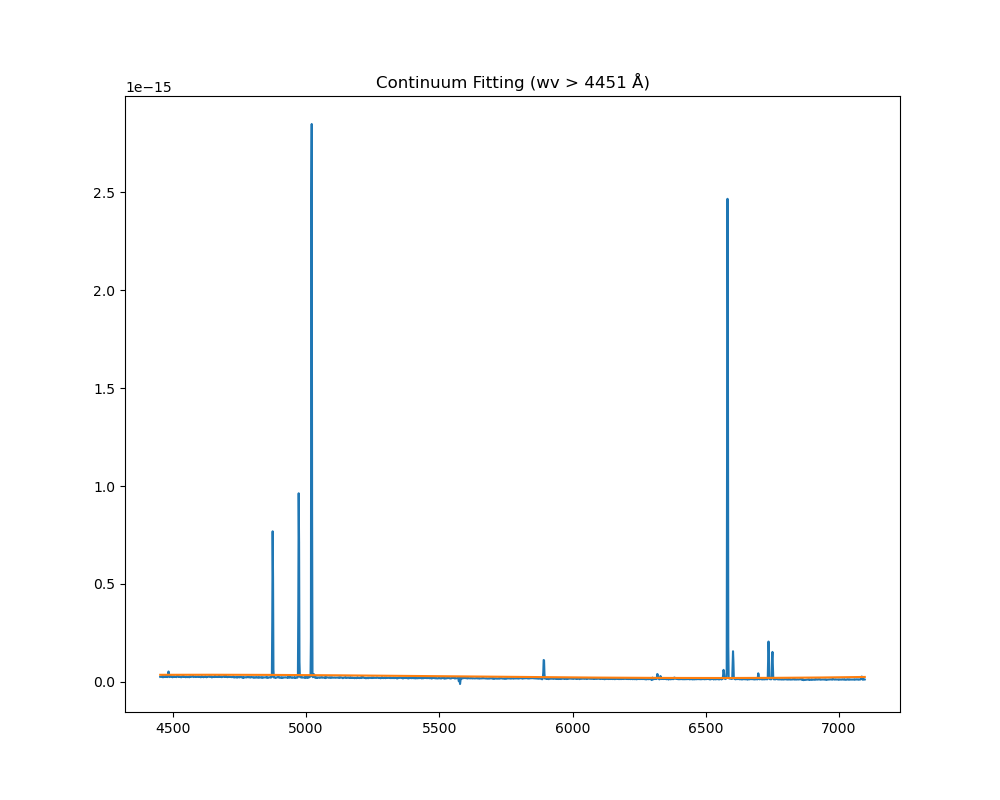

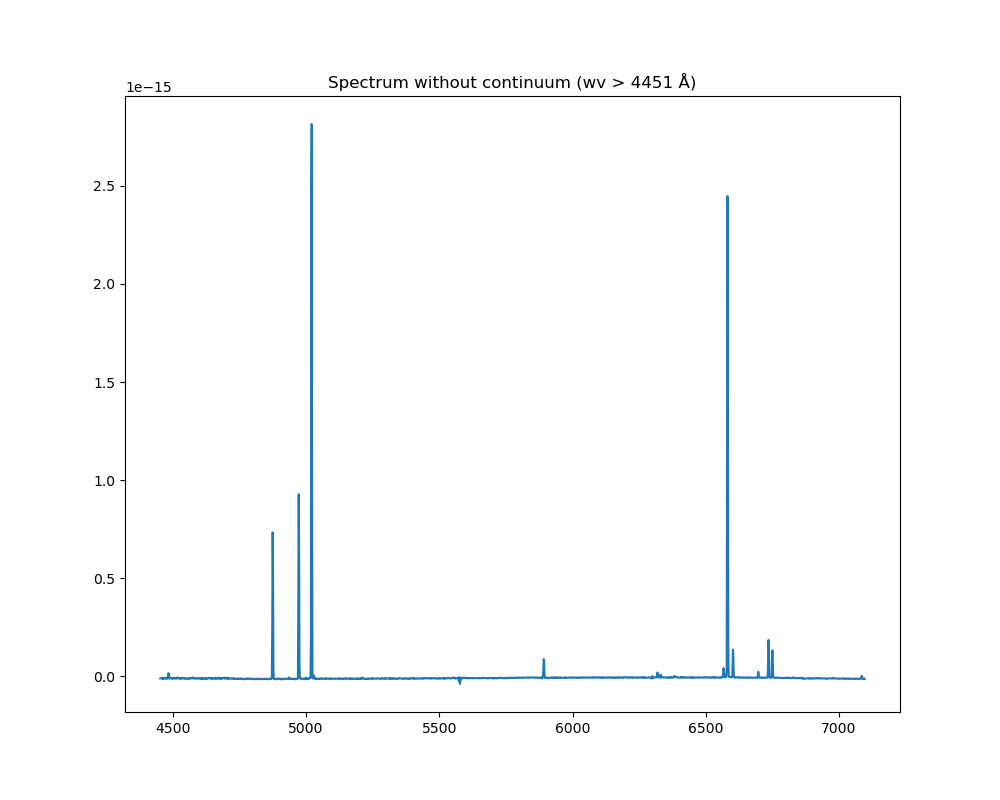

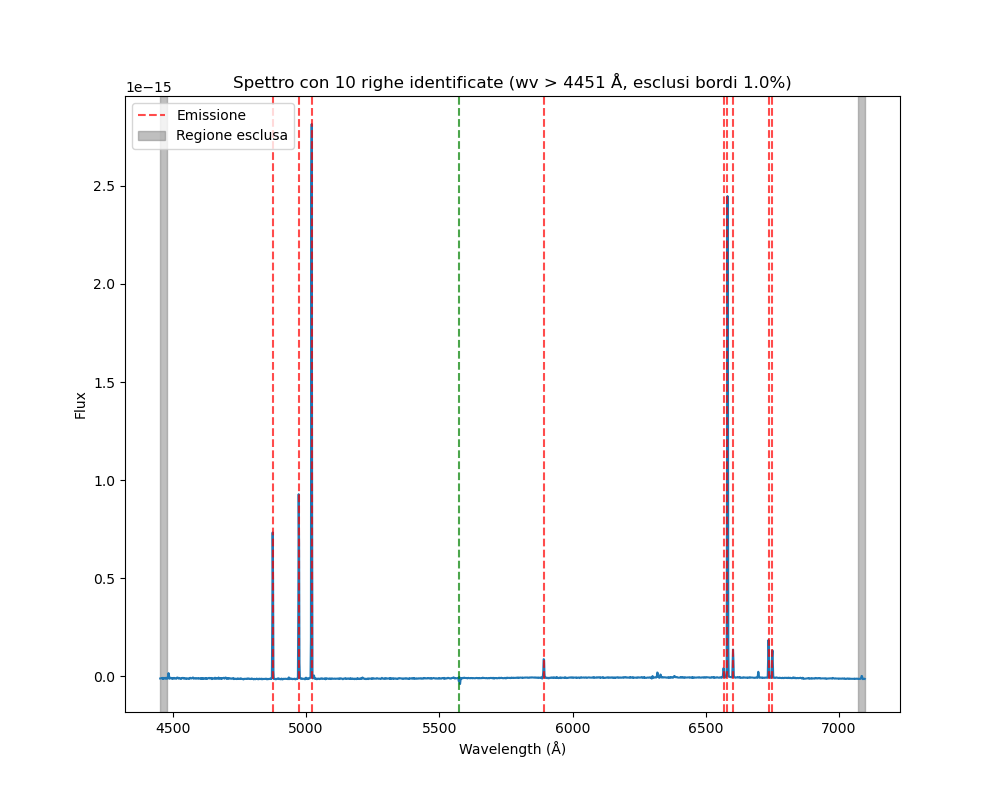

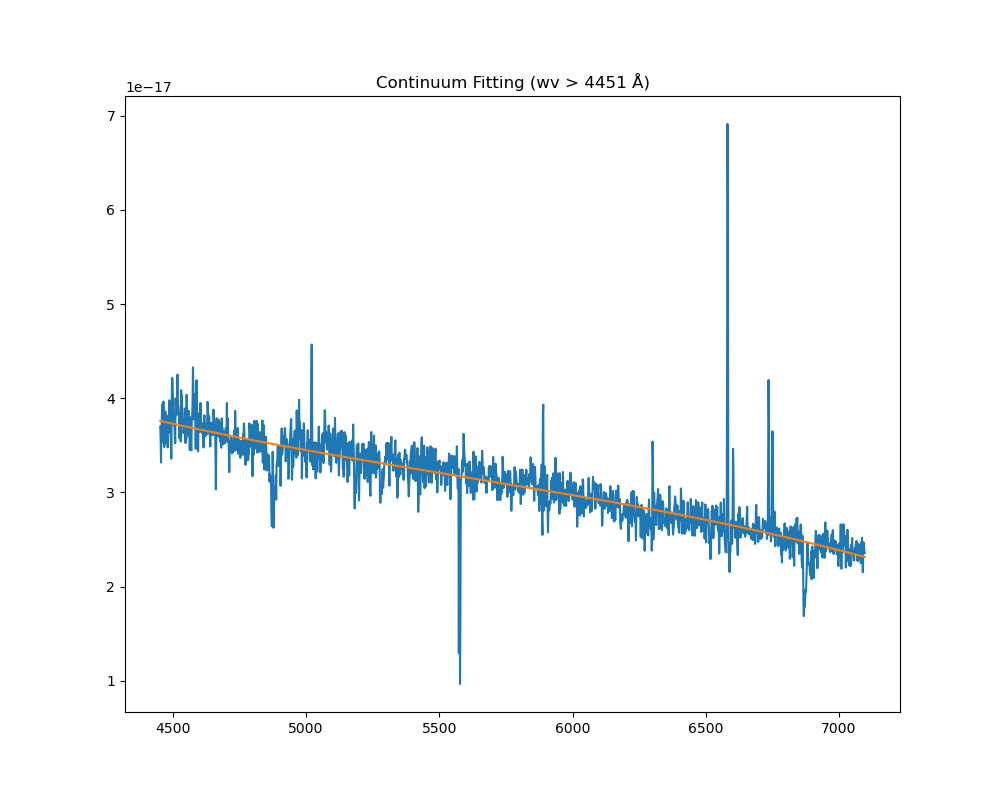

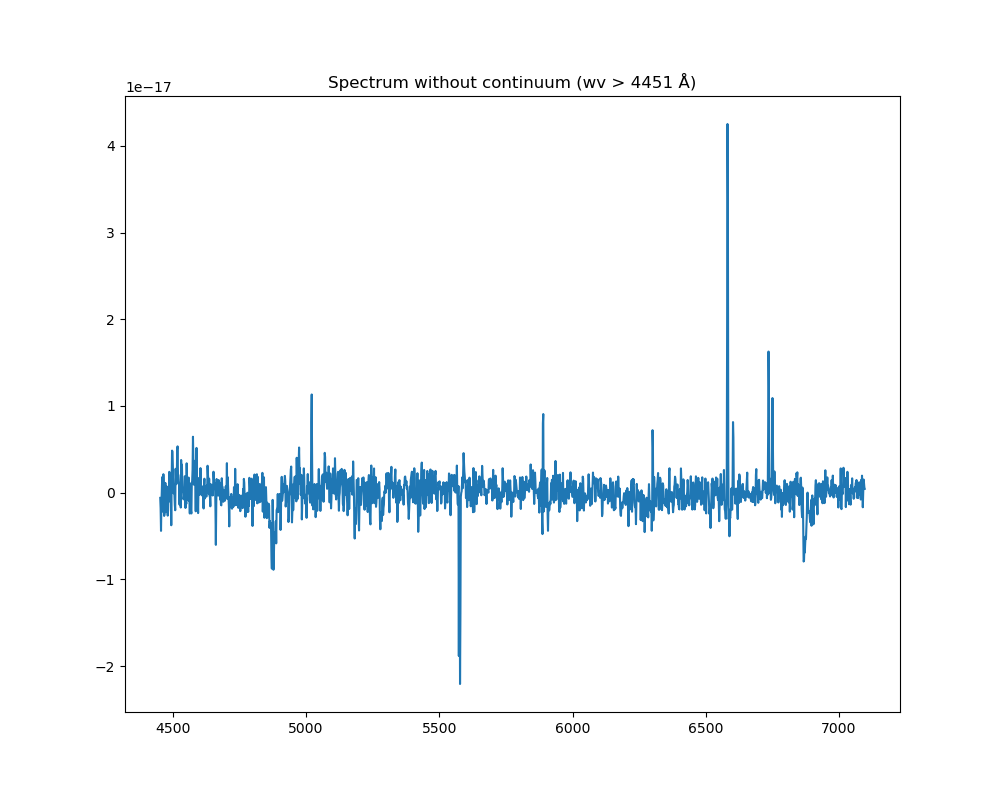

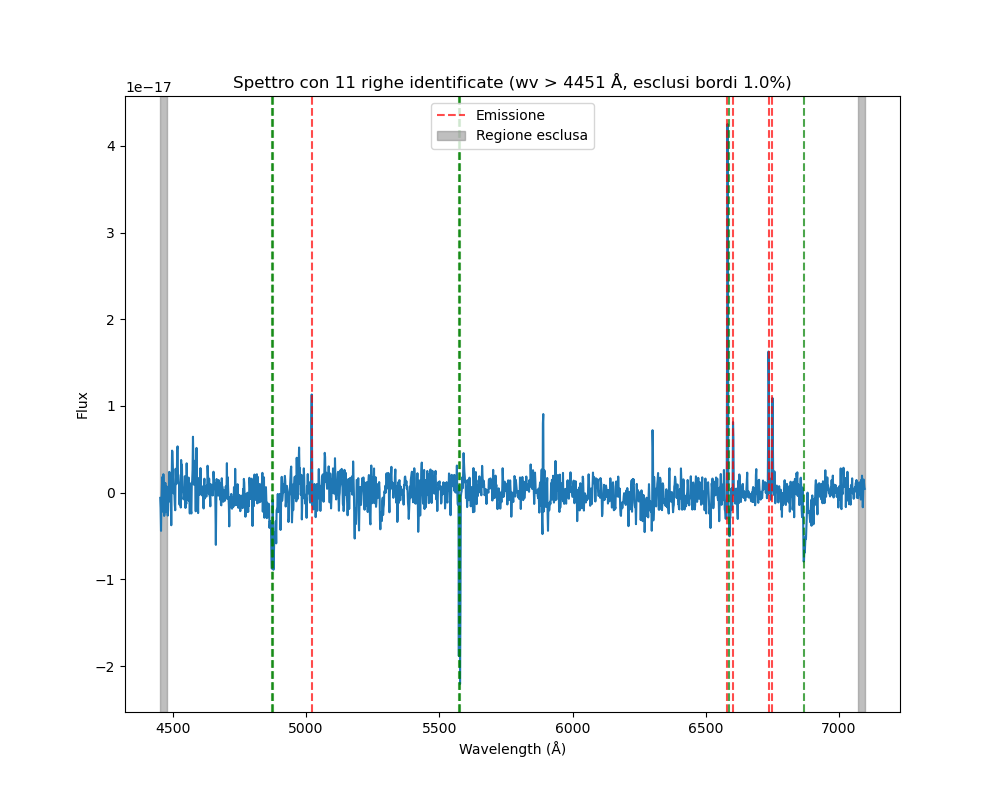

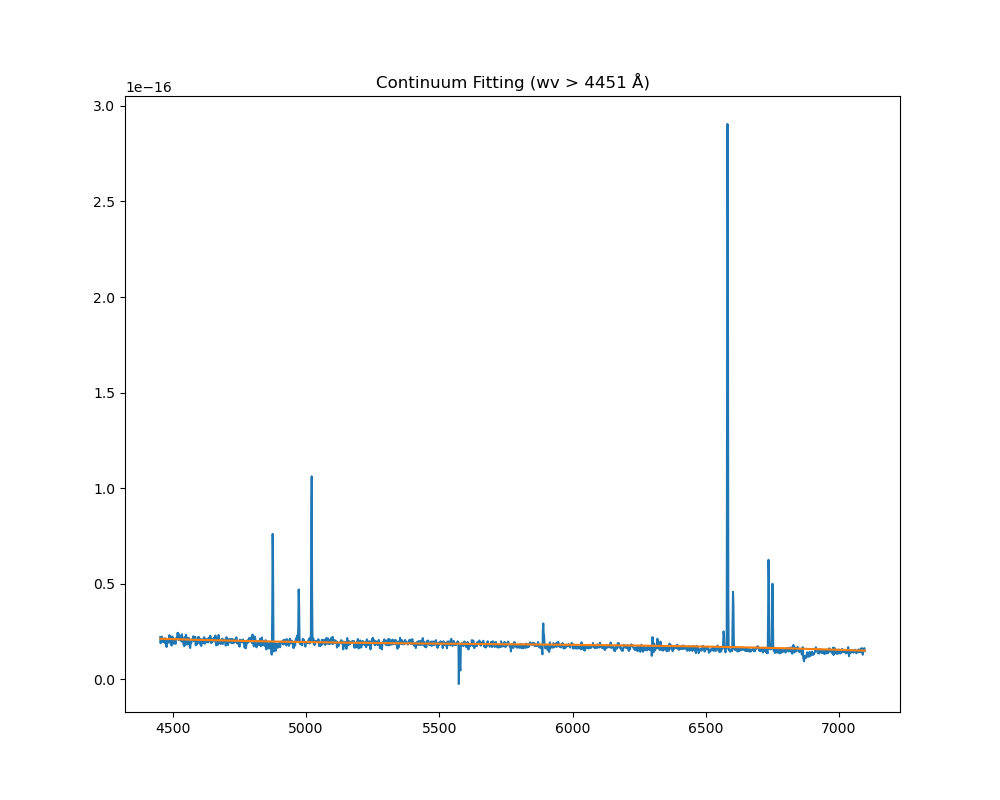

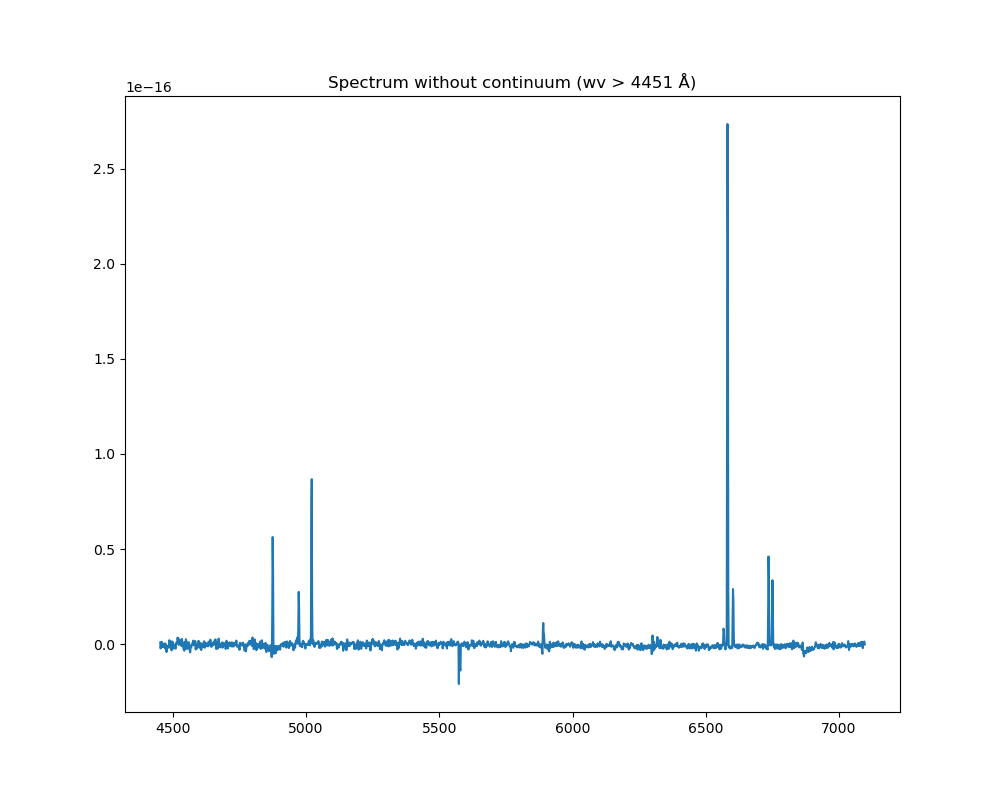

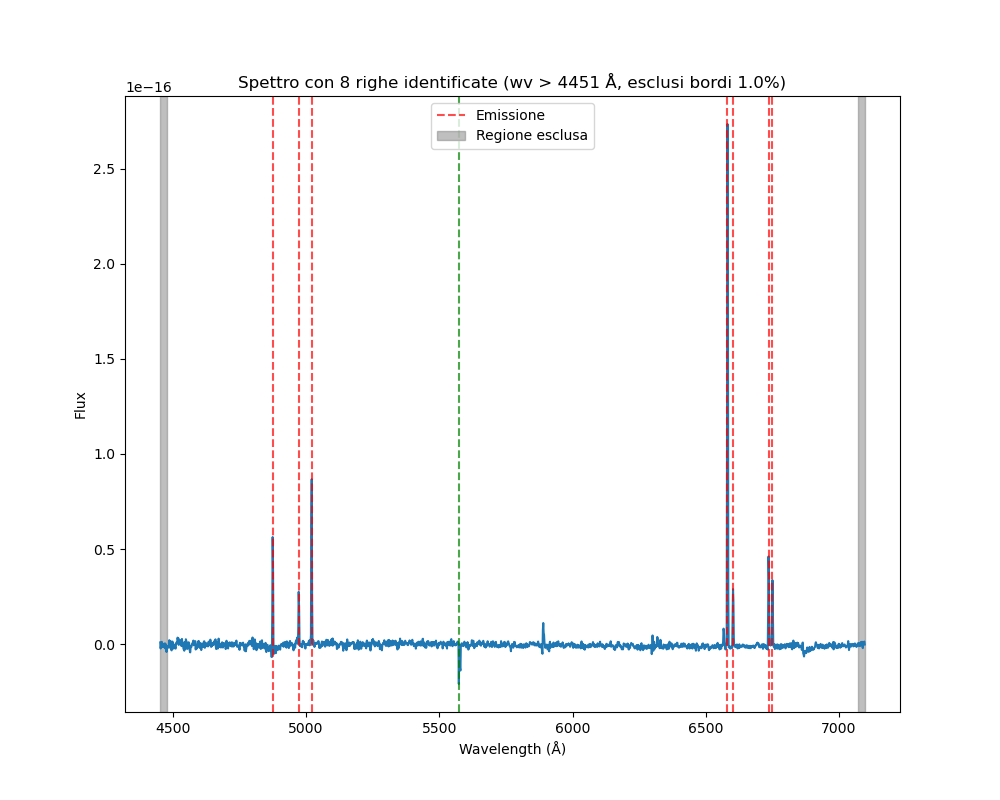

In [69]:
all_lines = []
noise_factor = [9, 12, 20, 5, 18]

# Filtra per lunghezze d'ondaù > 4451 Å
wv_mask = wv > 4452
wv_filtered = wv[wv_mask]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv_filtered)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale (già filtrata per wv > 4451)
wv_central = wv_filtered[start_idx:end_idx]

for i in range(len(peaks)):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra_3[i][wv_mask]
    spectra_err_filtered = spectra_err_3[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    f, ax = plt.subplots(figsize = (10,8))
    ax.plot(wv_filtered * u.Angstrom, spectra_filtered * 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    ax.plot(wv_filtered * u.Angstrom, y_continuum_fitted)
    ax.set_title("Continuum Fitting (wv > 4451 Å)")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    f2, ax2 = plt.subplots(figsize = (10,8))
    ax2.plot(wv_filtered * u.Angstrom, flux_continuum_subtracted)
    ax2.set_title("Spectrum without continuum (wv > 4451 Å)")
    
    # Crea lo spettro solo per la regione centrale (senza bordi, già filtrata per wv > 4451)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err_filtered[start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print('Spettro', i+1)
    print(f"Numero di righe trovate (regione centrale, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            # Trova l'indice più vicino alla posizione della riga nell'array wv_central
            line_idx = np.argmin(np.abs(wv_central - line_pos.value))
            # Ottieni l'indice corrispondente nel flux completo
            flux_idx = start_idx + line_idx
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[flux_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv_filtered[0], wv_filtered[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv_filtered[end_idx-1], wv_filtered[-1], alpha=0.5, color='gray', zorder=1)
    ax3.legend()
    
    ax3.set_title(f"Spettro con {len(lines)} righe identificate (wv > 4451 Å, esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [73]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6
l_OI = 6300.3

lines_1 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_2 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_3 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_4 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_5 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]

lines_spectrum_1 = all_lines[0]['line_center'] 
lines_spectrum_2 = all_lines[1]['line_center']
lines_spectrum_3 = all_lines[2]['line_center']
lines_spectrum_4 = all_lines[3]['line_center']
lines_spectrum_5 = all_lines[4]['line_center']

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
z_1_mean, z_1_std = redshift(lines_1, lines_spectrum_1)    
z_2_mean, z_2_std = redshift(lines_2, lines_spectrum_2)    
z_3_mean, z_3_std = redshift(lines_3, lines_spectrum_3)    
z_4_mean, z_4_std = redshift(lines_4, lines_spectrum_4)
z_5_mean, z_5_std = redshift(lines_5, lines_spectrum_5)

z = [z_1_mean, z_2_mean, z_3_mean, z_4_mean, z_5_mean]
z_err = [z_1_std, z_2_std, z_3_std, z_4_std, z_5_std]

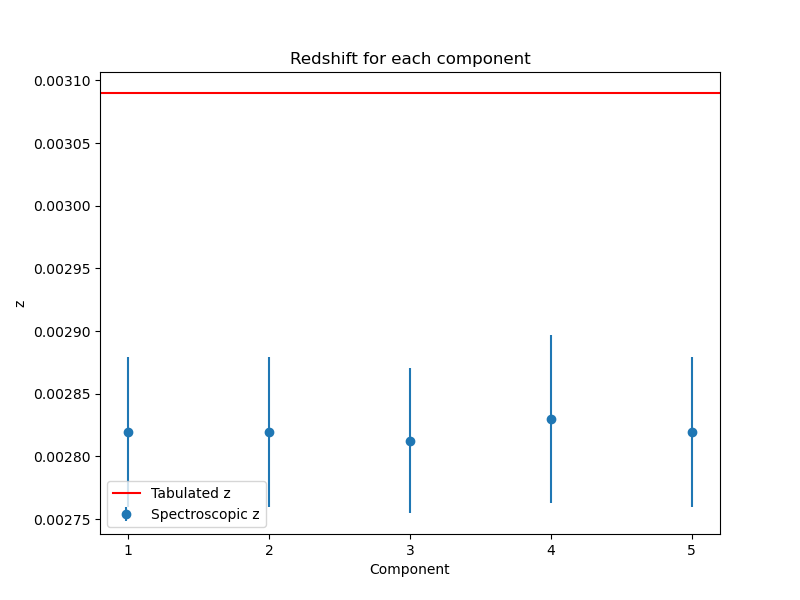

In [74]:
plt.figure(figsize=(8, 6))
comp = [1, 2, 3, 4, 5]
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
plt.axhline(0.00309, color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [75]:
def SNR_line(wv, wv_line, spectra, peaks): 
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > wv_line[i]-15)*(wv < wv_line[i]-5) 
        right_region = (wv > wv_line[i]+5)*(wv < wv_line[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > OIII_1[i]-15)*(wv < OIII_1[i]-5) 
        right_region = (wv > OIII_2[i]+5)*(wv < OIII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > SII_1[i]-15)*(wv < SII_1[i]-5) 
        right_region = (wv > SII_2[i]+5)*(wv < SII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > NII_1[i]-15)*(wv < NII_1[i]-5) 
        right_region = (wv > NII_2[i]+5)*(wv < NII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise  

In [76]:
l_Hgam = []
l_HA = []
l_HB = []
l_NII_1 = []
l_NII_2 = []
l_SII_1 = []
l_SII_2 = []
l_OIII_1 = []
l_OIII_2 = []
l_He_1 = []
for i in range(len(peaks)):
    l_Hgam.append(4340.5*(1+z[i]))
    l_HA.append(6562.8*(1+z[i]))
    l_HB.append(4861.3*(1+z[i]))
    l_NII_1.append(6548.1*(1+z[i]))
    l_NII_2.append(6583.4*(1+z[i]))
    l_SII_1.append(6717.0*(1+z[i]))
    l_SII_2.append(6731.3*(1+z[i]))
    l_OIII_1.append(4958.9*(1+z[i]))
    l_OIII_2.append(5006.8*(1+z[i]))
    l_He_1.append(5875.6*(1+z[i]))

In [77]:
def save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes):
    """
    Generalizza l'analisi SNR per multiple spectra
    
    Parameters:
    - wv: wavelength array
    - l_HB: line parameter
    - spectra_list: lista degli spettri da analizzare
    - peaks: peaks parameter
    - output_dirs: lista delle directory di output
    - file_prefixes: lista dei prefissi per i nomi dei file
    """
    
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_line(wv, l_HB, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')

def save_snr_OIII(wv, OIII_1, OIII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        
def save_snr_SII(wv, SII_1, SII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')


def save_snr_HA_NII(wv, NII_1, NII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')

In [78]:
spectra_list = [spectra_1, spectra_2, spectra_3]
output_dirs = ['1Sigma', '2Sigma', '3Sigma']
file_prefixes = ['SNR_HB_1s', 'SNR_HB_2s', 'SNR_HB_3s']
save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_1_1s', 'SNR_OIII_1_2s', 'SNR_OIII_1_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_2_1s', 'SNR_OIII_2_2s', 'SNR_OIII_2_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_1_1s', 'SNR_SII_1_2s', 'SNR_SII_1_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_2_1s', 'SNR_SII_2_2s', 'SNR_SII_2_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_1_1s', 'SNR_NII_1_2s', 'SNR_NII_1_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_2_1s', 'SNR_NII_2_2s', 'SNR_NII_2_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_HA_1s', 'SNR_HA_2s', 'SNR_HA_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra_list, peaks, output_dirs, file_prefixes)